# HUABB Health Study

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

import causalpype as cp
from causalpype import AnomalyAttribution
import matplotlib.pyplot as plt
from causalpype import ArrowStrength
from causalpype import ATE
from causalpype import CATE
from causalpype import Counterfactual
from causalpype import DistributionChange
from causalpype import CausalEffectCurve
from causalpype import FairnessAudit
from causalpype import Intervention
from causalpype import IntrinsicCausalInfluence
from causalpype import KNNIntervention
from causalpype import StochasticIntervention
from causalpype import Validate



## 1. Load Data and Expert Causal Graph

In [2]:
# Load the cleaned HUABB dataset
data = pd.read_csv("../HUABB_data_cleaned.csv", low_memory=False)
print(f"Dataset: {data.shape[0]:,} rows x {data.shape[1]} columns")

Dataset: 14,203 rows x 295 columns


In [ ]:
# Load the expert defined causal edge list
# The CSV header encodes the first edge (column names = first source/target pair)
edges_raw = pd.read_csv("../edge_list - causal_graph.csv")
first_edge = pd.DataFrame({"source": [edges_raw.columns[0]], "target": [edges_raw.columns[1]]})
edges_raw.columns = ["source", "target"]
edges_df = pd.concat([first_edge, edges_raw], ignore_index=True)

print(f"Expert graph: {len(edges_df)} directed edges, "
      f"{len(set(edges_df['source']) | set(edges_df['target']))} unique nodes")

Expert graph: 374 directed edges, 87 unique nodes


In [4]:
graph_nodes = set(edges_df["source"]) | set(edges_df["target"])
data_cols = set(data.columns)

not_in_data = graph_nodes - data_cols
in_data = graph_nodes & data_cols
empty_nodes = {col for col in in_data if data[col].isna().all()}
has_data = in_data - empty_nodes

print(f"Graph nodes not in data at all:      {len(not_in_data):>3d}  -> {sorted(not_in_data)}")
print(f"Graph nodes in data but 100% empty:  {len(empty_nodes):>3d}")
print(f"Graph nodes with actual data:        {len(has_data):>3d}")

print(f"\nUsable nodes ({len(has_data)}) — sorted by missingness:")
for n in sorted(has_data, key=lambda c: data[c].isna().mean()):
    pct = data[n].isna().mean() * 100
    bar = "█" * int(pct / 2)
    print(f"  {n:35s} {pct:5.1f}%  {bar}")

Graph nodes not in data at all:        1  -> ['salt_intake']
Graph nodes in data but 100% empty:   51
Graph nodes with actual data:         35

Usable nodes (35) — sorted by missingness:
  sex                                   5.2%  ██
  age                                   6.7%  ███
  bw                                    9.6%  ████
  bh                                    9.7%  ████
  whr                                  20.0%  ██████████
  employment                           28.1%  ██████████████
  social_integration                   31.7%  ███████████████
  smoking_status                       32.6%  ████████████████
  education_group                      39.2%  ███████████████████
  sleep_hours                          47.9%  ███████████████████████
  full_fat_dairies_day                 50.6%  █████████████████████████
  no_low_fat_dairies_day               50.6%  █████████████████████████
  full_fat_milk_day                    50.8%  █████████████████████████
  high_fat_cheese

## 2. Graph Pruning

The expert graph has 87 nodes but only 35 have any data at all. We prune systematically:

1. **Remove nodes not in data or 100% empty** (52 nodes) — entire variable categories (dietary percentages, detailed PA, health status) were never collected for this cohort
2. **Apply missingness threshold (60%)** — drops `sitting_day` (85.7%), `MET_week` (88.9%), `cigarettes_day` (61.6%), `lightbeverages_day` (70.7%), `age_quitting` (93.4%)
3. **Remove dead-end nodes** — `employment` only connected to the dropped `MET_week`/`PAL` nodes and `education_group`, becoming a leaf with no path to any outcome
4. **Add domain-justified edges** — `smoking_status -> bw` and `smoking_status -> whr` (smoking is a well-established determinant of body weight and fat distribution; the original graph had smoking edges to nodes that were 100% empty)

Note: `PAL` (Physical Activity Level, 59.4% missing) is kept as the sole physical activity indicator since it's just below the threshold and is an important body weight determinant.

In [5]:
# Step 1: Keep only edges where both endpoints have actual data
usable_edges = edges_df[
    edges_df["source"].isin(has_data) & edges_df["target"].isin(has_data)
].copy()
print(f"After removing empty/missing nodes: {len(usable_edges)} edges")

After removing empty/missing nodes: 25 edges


In [6]:
# Step 2: Apply missingness threshold — drop nodes with >60% missing
MISS_THRESHOLD = 0.60
high_missing = {col for col in has_data if data[col].isna().mean() > MISS_THRESHOLD}
print(f"Dropped (>{MISS_THRESHOLD:.0%} missing): {sorted(high_missing)}")

usable_edges = usable_edges[
    ~usable_edges["source"].isin(high_missing) & ~usable_edges["target"].isin(high_missing)
]

Dropped (>60% missing): ['MET_week', 'age_quitting', 'cigarettes_day', 'lightbeverages_day', 'sitting_day']


In [7]:
# Step 3: Add domain-justified smoking edges
smoking_edges = pd.DataFrame({
    "source": ["smoking_status"],
    "target": ["bw"]
})
usable_edges = pd.concat([usable_edges, smoking_edges], ignore_index=True)


In [8]:
# Build adjacency dict for CausalPype
from collections import defaultdict
adj = defaultdict(list)
for _, row in usable_edges.iterrows():
    adj[row["source"]].append(row["target"])

# Verify DAG
G = nx.DiGraph(dict(adj))
assert nx.is_directed_acyclic_graph(G), f"Cycle detected: {list(nx.find_cycle(G))}"

roots = [n for n in G if G.in_degree(n) == 0]
leaves = [n for n in G if G.out_degree(n) == 0]
print(f"\nFinal graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Root nodes (exogenous):  {sorted(roots)}")
print(f"Leaf nodes (outcomes):   {sorted(leaves)}")
print(f"\nEdge list:")
for src in sorted(adj.keys()):
    if adj[src]:
        print(f"  {src} -> {sorted(adj[src])}")


Final graph: 13 nodes, 20 edges
Root nodes (exogenous):  ['age', 'education_group', 'energy_intake_day', 'sex', 'smoking_status', 'social_integration', 'sugarsweetenedbeverages_day']
Leaf nodes (outcomes):   ['bw', 'whr']

Edge list:
  PAL -> ['bw']
  age -> ['PAL', 'bw', 'sleep_hours', 'whr']
  bh -> ['bw']
  education_group -> ['bw', 'employment']
  employment -> ['PAL']
  energy_intake_day -> ['bw', 'whr']
  sex -> ['PAL', 'bh', 'bw', 'whr']
  sleep_hours -> ['bw']
  smoking_status -> ['bw']
  social_integration -> ['bw']
  sugarsweetenedbeverages_day -> ['bw', 'whr']


## 3. Data Preprocessing

### Variable types
- **Continuous** (8): `age`, `bh` (body height), `bw` (body weight), `whr` (waist-to-hip ratio), `energy_intake_day`, `sleep_hours`, `sugarsweetenedbeverages_day`, `PAL` (physical activity level)
- **Categorical** (4): `sex` (1=male, 2=female), `education_group` (1, 2, 4), `social_integration` (0/1), `smoking_status` (0/1)

### Imputation strategy
1. **Categoricals** — mode imputation (most frequent category)
2. **Continuous** — `IterativeImputer` with `BayesianRidge`


In [9]:
# Select only the columns needed for the causal graph
graph_cols = sorted(G.nodes)
df = data[graph_cols].copy()

print(f"Selected {len(graph_cols)} columns, {len(df):,} rows\n")
print("Missingness summary:")
missing = df.isna().mean().sort_values(ascending=False) * 100
for col, pct in missing.items():
    bar = "█" * int(pct / 2)
    print(f"  {col:35s} {pct:5.1f}%  {bar}")

complete = df.dropna().shape[0]
print(f"\nComplete cases: {complete:,} / {len(df):,} ({complete/len(df):.1%})")

Selected 13 columns, 14,203 rows

Missingness summary:
  PAL                                  59.4%  █████████████████████████████
  energy_intake_day                    51.0%  █████████████████████████
  sugarsweetenedbeverages_day          50.8%  █████████████████████████
  sleep_hours                          47.9%  ███████████████████████
  education_group                      39.2%  ███████████████████
  smoking_status                       32.6%  ████████████████
  social_integration                   31.7%  ███████████████
  employment                           28.1%  ██████████████
  whr                                  20.0%  ██████████
  bh                                    9.7%  ████
  bw                                    9.6%  ████
  age                                   6.7%  ███
  sex                                   5.2%  ██

Complete cases: 2,360 / 14,203 (16.6%)


In [10]:
# Inspect categorical variables before imputation
cat_cols = ["sex", "education_group", "social_integration", "smoking_status", "employment"]
cont_cols = [c for c in graph_cols if c not in cat_cols]

for col in cat_cols:
    vals = df[col].dropna()
    print(f"{col}: {vals.nunique()} categories, values={sorted(vals.unique())}, "
          f"missing={df[col].isna().sum()} ({df[col].isna().mean():.1%})")
    print(f"  {vals.value_counts().sort_index().to_dict()}\n")

sex: 2 categories, values=[np.float64(1.0), np.float64(2.0)], missing=737 (5.2%)
  {1.0: 6171, 2.0: 7295}

education_group: 3 categories, values=[np.float64(1.0), np.float64(2.0), np.float64(4.0)], missing=5568 (39.2%)
  {1.0: 3815, 2.0: 2831, 4.0: 1989}

social_integration: 2 categories, values=[np.float64(0.0), np.float64(1.0)], missing=4503 (31.7%)
  {0.0: 7511, 1.0: 2189}

smoking_status: 2 categories, values=[np.float64(0.0), np.float64(1.0)], missing=4629 (32.6%)
  {0.0: 6111, 1.0: 3463}

employment: 5 categories, values=[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)], missing=3992 (28.1%)
  {0.0: 1497, 1.0: 2631, 2.0: 1884, 3.0: 2468, 4.0: 1731}



In [11]:
# Phase 1: Impute categoricals with mode (most frequent category)
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Convert to proper categorical dtype
# DoWhy's auto.assign_causal_mechanisms checks dtype to assign ClassifierFCM vs regressors
for col in cat_cols:
    df[col] = df[col].astype(int).astype("category")

print("Categorical imputation complete:")
for col in cat_cols:
    print(f"  {col}: dtype={df[col].dtype}, categories={df[col].cat.categories.tolist()}, "
          f"missing={df[col].isna().sum()}")

Categorical imputation complete:
  sex: dtype=category, categories=[1, 2], missing=0
  education_group: dtype=category, categories=[1, 2, 4], missing=0
  social_integration: dtype=category, categories=[0, 1], missing=0
  smoking_status: dtype=category, categories=[0, 1], missing=0
  employment: dtype=category, categories=[0, 1, 2, 3, 4], missing=0


In [ ]:
# Phase 2: Impute continuous variables with IterativeImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

print(f"Continuous columns ({len(cont_cols)}): {cont_cols}")
print(f"\nMissing before imputation:")
for c in cont_cols:
    print(f"  {c:35s} {df[c].isna().sum():>5d} ({df[c].isna().mean():.1%})")

df_for_mice = df.copy()
for col in cat_cols:
    df_for_mice[col] = df_for_mice[col].cat.codes.astype(float)

mice = IterativeImputer(max_iter=20, random_state=42, sample_posterior=False)
imputed_values = pd.DataFrame(
    mice.fit_transform(df_for_mice),
    columns=df_for_mice.columns,
    index=df_for_mice.index,
)

# Write back only the continuous columns (categoricals already imputed)
for col in cont_cols:
    df[col] = imputed_values[col].values

# Restore categorical dtypes
for col in cat_cols:
    df[col] = df[col].astype("category")

assert df.isna().sum().sum() == 0, "Still have missing values!"
print(f"\nImputation complete. Zero missing values confirmed.")
print(f"Final shape: {df.shape}")

Continuous columns (8): ['PAL', 'age', 'bh', 'bw', 'energy_intake_day', 'sleep_hours', 'sugarsweetenedbeverages_day', 'whr']

Missing before imputation:
  PAL                                  8437 (59.4%)
  age                                   947 (6.7%)
  bh                                   1371 (9.7%)
  bw                                   1369 (9.6%)
  energy_intake_day                    7239 (51.0%)
  sleep_hours                          6799 (47.9%)
  sugarsweetenedbeverages_day          7216 (50.8%)
  whr                                  2844 (20.0%)

Imputation complete. Zero missing values confirmed.
Final shape: (14203, 13)


In [13]:
# Post-imputation sanity checks
print("Continuous variable statistics after imputation:")
print(df[cont_cols].describe().round(2).to_string())

# Flag any implausible values
print("\n\nPlausibility checks:")
checks = {
    "age": (0, 120, "years"),
    "bh": (50, 250, "cm"),
    "bw": (10, 300, "kg"),
    "whr": (0.4, 1.5, "ratio"),
    "energy_intake_day": (0, 10000, "kcal"),
    "sleep_hours": (0, 24, "hours"),
    "sugarsweetenedbeverages_day": (0, None, "g"),
    "PAL": (0, 5, "ratio"),
}
for col, (lo, hi, unit) in checks.items():
    vals = df[col]
    issues = []
    if lo is not None and (vals < lo).any():
        issues.append(f"{(vals < lo).sum()} below {lo}")
    if hi is not None and (vals > hi).any():
        issues.append(f"{(vals > hi).sum()} above {hi}")
    status = ", ".join(issues) if issues else "OK"
    print(f"  {col:35s} [{lo}-{hi} {unit}]: {status}")

print("\nCategorical distributions:")
for col in cat_cols:
    print(f"  {col}: {df[col].value_counts().sort_index().to_dict()}")

Continuous variable statistics after imputation:
            PAL       age        bh        bw  energy_intake_day  sleep_hours  sugarsweetenedbeverages_day       whr
count  14203.00  14203.00  14203.00  14203.00           14203.00     14203.00                     14203.00  14203.00
mean       1.21     48.08    164.79     74.89            2168.06         7.24                         1.59      0.89
std        0.19     20.57     10.49     18.52             638.55         1.28                         1.63      0.14
min        0.65      9.00      1.78     24.70              -9.00        -0.47                         0.00      0.00
25%        1.07     35.00    158.00     64.00            1932.41         6.69                         1.20      0.81
50%        1.18     50.00    164.86     74.00            2130.27         7.19                         1.55      0.89
75%        1.30     64.00    172.00     85.00            2344.87         8.00                         1.77      0.96
max        2.51

## 4. Build and Fit the Causal Model

The pruned DAG encodes the following causal structure:

**Exogenous (root) nodes**: age, sex, education_group, energy_intake_day, sleep_hours, social_integration, sugarsweetenedbeverages_day, smoking_status

**Mediators**: bh (body height), PAL (physical activity level), sleep_hours

**Outcome (leaf) nodes**: bw (body weight), whr (waist-to-hip ratio)

**Key causal pathways to body weight**:
- **Demographics**: age -> bw, sex -> bw, education_group -> bw
- **Anthropometric**: sex -> bh -> bw (height mediates sex's effect on weight)
- **Physical activity**: age/sex -> PAL -> bw
- **Nutrition**: energy_intake_day -> bw, sugarsweetenedbeverages_day -> bw
- **Lifestyle**: sleep_hours -> bw, social_integration -> bw, smoking_status -> bw

In [14]:

model = cp.CausalModel(G)
print(model)
print(f"\nRoot nodes:  {model.get_roots()}")

CausalModel(not fitted, nodes=['age', 'bh', 'education_group', 'employment', 'energy_intake_day', 'PAL', 'sex', 'sleep_hours', 'social_integration', 'sugarsweetenedbeverages_day', 'smoking_status', 'bw', 'whr'], edges=[('age', 'sleep_hours'), ('age', 'bw'), ('age', 'PAL'), ('age', 'whr'), ('bh', 'bw'), ('education_group', 'employment'), ('education_group', 'bw'), ('employment', 'PAL'), ('energy_intake_day', 'bw'), ('energy_intake_day', 'whr'), ('PAL', 'bw'), ('sex', 'bh'), ('sex', 'bw'), ('sex', 'PAL'), ('sex', 'whr'), ('sleep_hours', 'bw'), ('social_integration', 'bw'), ('sugarsweetenedbeverages_day', 'bw'), ('sugarsweetenedbeverages_day', 'whr'), ('smoking_status', 'bw')])

Root nodes:  ['age', 'education_group', 'energy_intake_day', 'sex', 'social_integration', 'sugarsweetenedbeverages_day', 'smoking_status']


(<Figure size 1400x1000 with 1 Axes>, <Axes: title={'center': 'Causal Graph'}>)

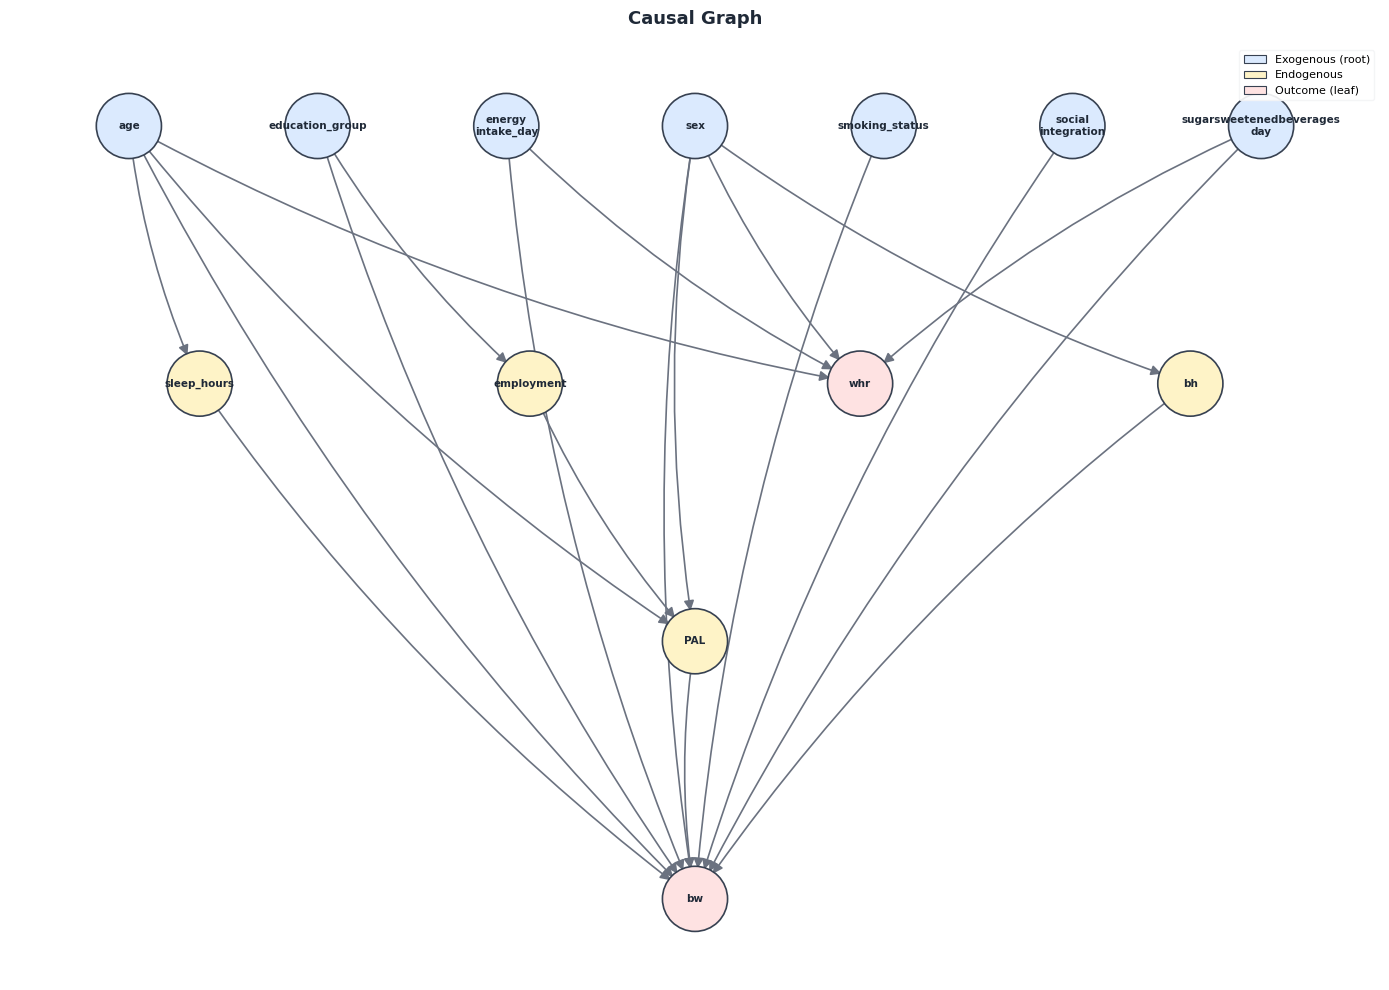

In [15]:
cp.plotting.plot_graph(model)

In [16]:
model.fit(df)
print(model)

Fitting causal mechanism of node whr: 100%|██████████| 13/13 [00:04<00:00,  2.77it/s]                       

CausalModel(fitted, nodes=['age', 'bh', 'education_group', 'employment', 'energy_intake_day', 'PAL', 'sex', 'sleep_hours', 'social_integration', 'sugarsweetenedbeverages_day', 'smoking_status', 'bw', 'whr'], edges=[('age', 'sleep_hours'), ('age', 'bw'), ('age', 'PAL'), ('age', 'whr'), ('bh', 'bw'), ('education_group', 'employment'), ('education_group', 'bw'), ('employment', 'PAL'), ('energy_intake_day', 'bw'), ('energy_intake_day', 'whr'), ('PAL', 'bw'), ('sex', 'bh'), ('sex', 'bw'), ('sex', 'PAL'), ('sex', 'whr'), ('sleep_hours', 'bw'), ('social_integration', 'bw'), ('sugarsweetenedbeverages_day', 'bw'), ('sugarsweetenedbeverages_day', 'whr'), ('smoking_status', 'bw')])


In [17]:
# Verify assigned causal mechanisms
print("Assigned causal mechanisms:")
for node in sorted(model.graph.nodes):
    mechanism = model.scm.causal_mechanism(node)
    mtype = type(mechanism).__name__
    print(f"  {node:35s} {mtype}")

# Quick sanity check: synthetic samples vs observed
synthetic = model.draw_samples(n=2000)
print("\nSynthetic vs. observed means (continuous):")
for col in cont_cols:
    obs_mean = df[col].mean()
    syn_mean = synthetic[col].mean()
    print(f"  {col:35s} observed={obs_mean:8.2f}  synthetic={syn_mean:8.2f}")

Assigned causal mechanisms:
  PAL                                 AdditiveNoiseModel
  age                                 EmpiricalDistribution
  bh                                  AdditiveNoiseModel
  bw                                  AdditiveNoiseModel
  education_group                     EmpiricalDistribution
  employment                          DiscreteAdditiveNoiseModel
  energy_intake_day                   EmpiricalDistribution
  sex                                 EmpiricalDistribution
  sleep_hours                         AdditiveNoiseModel
  smoking_status                      EmpiricalDistribution
  social_integration                  EmpiricalDistribution
  sugarsweetenedbeverages_day         EmpiricalDistribution
  whr                                 AdditiveNoiseModel

Synthetic vs. observed means (continuous):
  PAL                                 observed=    1.21  synthetic=    1.20
  age                                 observed=   48.08  synthetic=   48.22
  bh  

## Experiments

## 1. Anomaly Attribution

**Clinical question**: *A clinician identifies patients with abnormally high body weight. Among the upstream causal factors, age, sex, height, diet, physical activity, sleep, smoking, social integration, which ones contribute most to making these patients' weight anomalous?*

In [22]:
from causalpype import AnomalyAttribution

# Auto detect anomalies. Top 5% most extreme body weights
task = AnomalyAttribution(
    target="bw",
    anomaly_threshold_percentile=95,
)

result = model.run(task)
result

Estimating conditional anomaly scores:   8%|▊         | 1/13 [00:03<00:36,  3.02s/it]


KeyboardInterrupt: 

In [25]:
result

TaskResult(Anomaly Attribution: {'age': -0.15563044930403658, 'education_group': 0.09256496345178292, 'energy_intake_day': 0.5424267256538525, 'sex': 0.01475470607843433, 'social_integration': 0.01191399561485431, 'sugarsweetenedbeverages_day': 0.5663972848826085, 'smoking_status': 0.13249502132462512, 'sleep_hours': 0.8791933505724405, 'employment': 0.06603704202610511, 'bh': -0.2405233711493413, 'PAL': 0.21566513075701843, 'bw': 1.0486929246718637})

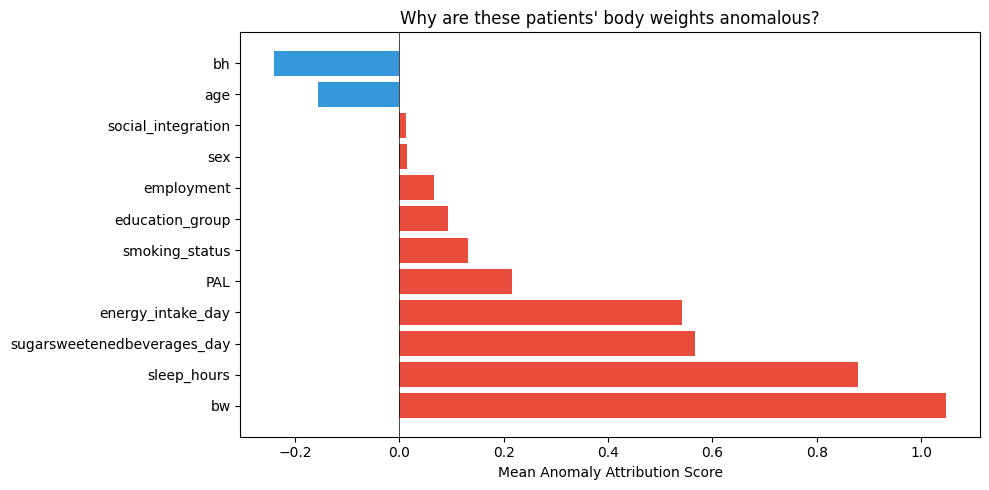

In [28]:
import matplotlib.pyplot as plt

attrs = result.details["mean_attributions"]
attrs_sorted = dict(sorted(attrs.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in attrs_sorted.values()]
ax.barh(list(attrs_sorted.keys()), list(attrs_sorted.values()), color=colors)
ax.set_xlabel("Mean Anomaly Attribution Score")
ax.set_title("Why are these patients' body weights anomalous?")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [21]:
obese_samples = df[df["bw"] > 140].copy()
print(f"Obese patients (bw > 140 kg): {len(obese_samples)}")

task_obese = AnomalyAttribution(
    target="bw",
    anomaly_data=obese_samples,
)

result_obese = model.run(task_obese)

Obese patients (bw > 140 kg): 49


Evaluating set functions...: 100%|██████████| 239/239 [02:26<00:00,  1.63it/s]


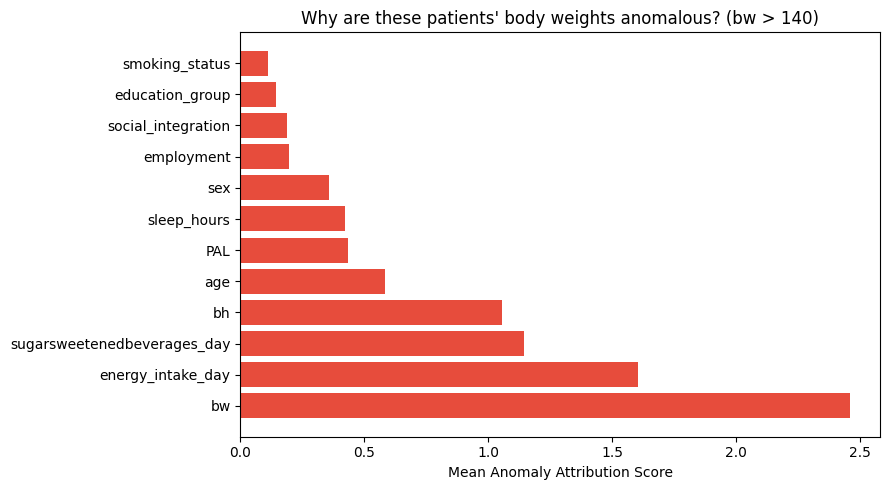

In [25]:
cp.plotting.plot_anomalies(result_obese, title="Why are these patients' body weights anomalous? (bw > 140)")

## 2. Arrow Strength

**Clinical question**: *Our causal graph has 10 edges pointing into body weight, but which causal links actually matter most? *


In [27]:
task = ArrowStrength(target="bw")
result = model.run(task)
result

TaskResult(Arrow Strength: {'PAL -> bw': 16.22713596586351, 'age -> bw': 46.91753887553703, 'bh -> bw': 57.374293897758506, 'education_group -> bw': 1.6642615245807568, 'energy_intake_day -> bw': 37.1902822464479, 'sex -> bw': 3.96017153874384, 'sleep_hours -> bw': 4.013665688247528, 'smoking_status -> bw': 0.4803395008901728, 'social_integration -> bw': 3.9070337194090006, 'sugarsweetenedbeverages_day -> bw': 13.298189454978546})

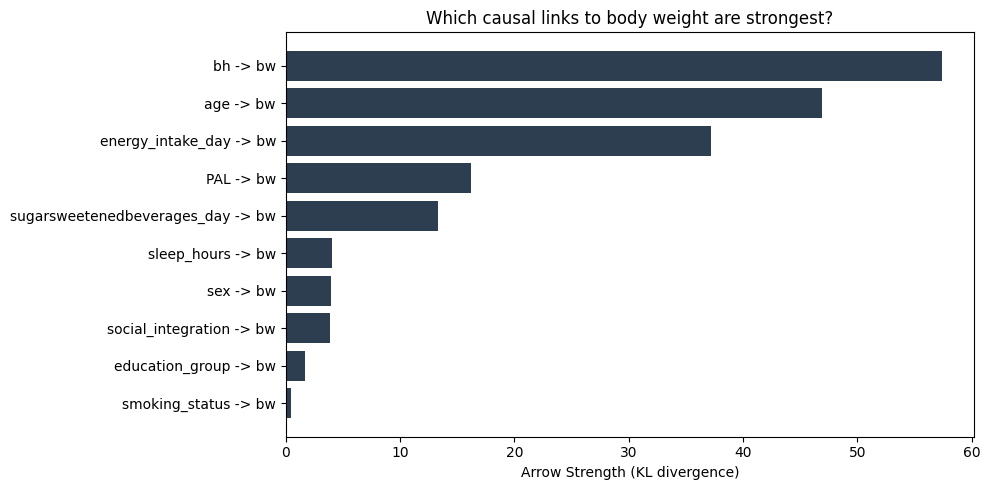

In [ ]:
cp.plotting.plot_arrow_strength(result, "Which causal links to body weight are strongest?")

## 3. Average Treatment Effect (ATE)

**Clinical question**: *Does smoking cause higher body weight? If we could intervene on the entire population and switch everyone from non-smoking to smoking (or vice versa), what would be the average causal effect on body weight?*


In [18]:
task = ATE(
    treatment="smoking_status",
    outcome="bw",
    treatment_value=1,   # smoker
    control_value=0,     # non-smoker
    num_samples=5000,
)

result = model.run(task)
result.summary()

╭────────────────────── ATE ───────────────────────╮
│                                                  │
│  Estimate: ↓ -1.0753                             │
│   Treatment                     smoking_status   │
│   Outcome                       bw               │
│   Treatment Value               1                │
│   Control Value                 0                │
│   Num Samples                   5,000            │
│                                                  │
╰──────────────────────────────────────────────────╯

''

## 4. Conditional ATE (CATE)

**Clinical question**: *Does the causal effect of smoking on body weight differ by age and sex? Is smoking more strongly associated with weight gain in older adults than in teenagers? Do men and women respond differently?*


In [21]:
task = CATE(
    treatment="smoking_status",
    outcome="bw",
    effect_modifiers=["age", "sex"],
    method="linear_dml",
)

result = model.run(task)
result.summary()

╭───────────────────────── CATE ─────────────────────────╮
│                                                        │
│  Estimate: ↓ -3.4959                                   │
│   Treatment                     smoking_status         │
│   Outcome                       bw                     │
│   Effect Modifiers              age, sex               │
│   Method                        linear_dml             │
│   Mean Effect                   ↓ -3.4959              │
│   STD Effect                    ↑ 1.0591               │
│   Bounds                        ↓ -4.5544, ↓ -2.1215   │
│                                                        │
╰────────────────────────────────────────────────────────╯

''

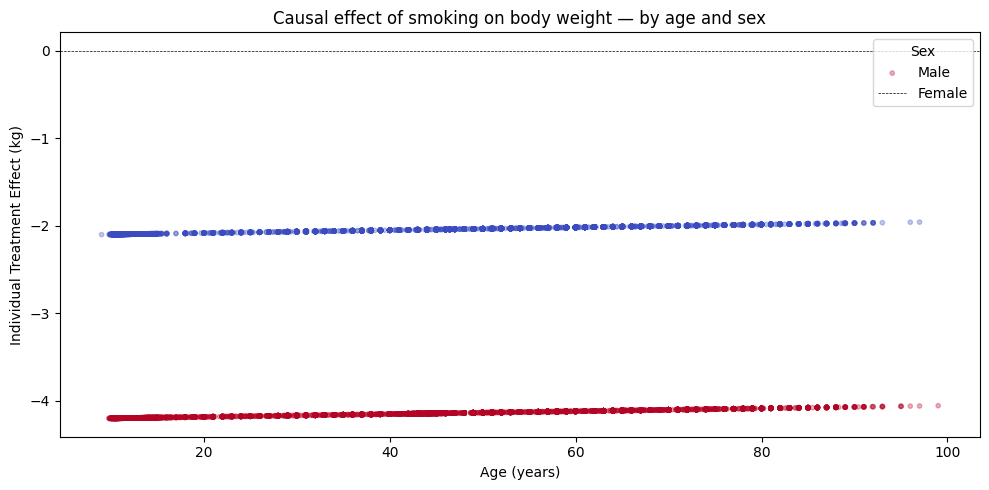

In [34]:
import matplotlib.pyplot as plt

effects = result.details["individual_effects"].flatten()
ages = df["age"].values

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(ages, effects, c=df["sex"].cat.codes, cmap="coolwarm", alpha=0.3, s=10)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Individual Treatment Effect (kg)")
ax.set_title("Causal effect of smoking on body weight — by age and sex")
ax.legend(*scatter.legend_elements(), labels=["Male", "Female"], title="Sex")
plt.tight_layout()
plt.show()


In [36]:
task_cf = CATE(
    treatment="smoking_status",
    outcome="bw",
    effect_modifiers=["age", "sex", "energy_intake_day"],
    method="causal_forest",
)

result_cf = model.run(task_cf)
result_cf

TaskResult(CATE: -2.703784)

In [38]:

result_cf.summary()


'CATE\n────\n  Estimate: ↓ -2.7038\n  Treatment: smoking_status\n  Outcome: bw\n  Effect Modifiers: age, sex, energy_intake_day\n  Method: causal_forest\n  Mean Effect: ↓ -2.7038\n  STD Effect: ↑ 4.6971\n  Bounds: ↓ -93.3533, ↑ 69.4355'

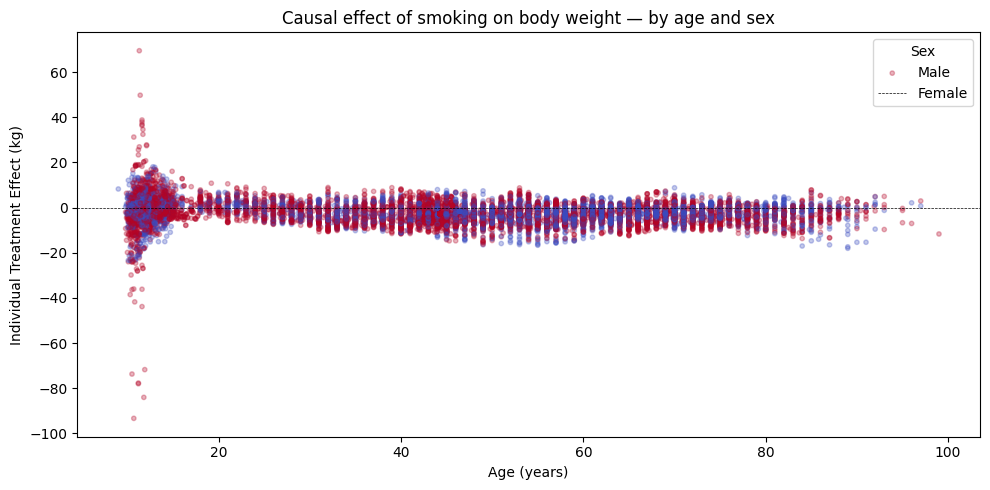

In [39]:
import matplotlib.pyplot as plt

effects = result_cf.details["individual_effects"].flatten()
ages = df["age"].values

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(ages, effects, c=df["sex"].cat.codes, cmap="coolwarm", alpha=0.3, s=10)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Individual Treatment Effect (kg)")
ax.set_title("Causal effect of smoking on body weight — by age and sex")
ax.legend(*scatter.legend_elements(), labels=["Male", "Female"], title="Sex")
plt.tight_layout()
plt.show()


## 5. Counterfactual Analysis

**Clinical question**: *For our heaviest patients (bw > 110 kg), what would their body weight have been if they had been physically active (PAL = 1.5) and slept 8 hours per night, while keeping everything else about them the same?*


In [41]:
obese = df[df["bw"] > 110].copy()
print(f"Patients with bw > 110 kg: {len(obese)}")
print(f"Mean actual weight: {obese['bw'].mean():.1f} kg")

task = Counterfactual(
    interventions={"PAL": 1.5, "sleep_hours": 8.0},
    observed_data=obese,
    outcome="bw",
)

result = model.run(task)
result.summary()

Patients with bw > 110 kg: 503
Mean actual weight: 123.6 kg


'Counterfactual\n──────────────\n  Estimate: ↑ 108.6265\n  Interventions:\n    sleep_hours                         ↑ 8.0000\n    PAL                                 ↑ 1.5000\n  N Units: 503\n  Outcome: bw\n  Factual Mean: ↑ 123.5533\n  Counterfactual Mean: ↑ 108.6265\n  Mean Effect: ↓ -14.9268'

## 6. Distribution Change

**Clinical question**: *Body weight is higher in adults (age ≥ 30) than in adolescents (age < 18), but which causal mechanisms are responsible for this shift? Is it simply that adults are taller, or do changes in diet, physical activity, and sleep patterns also contribute?*


In [44]:
young = df[df["age"] < 18].copy()
adult = df[df["age"] >= 30].copy()

print(f"Adolescents (age < 18): n={len(young)}, mean bw={young['bw'].mean():.1f} kg")
print(f"Adults (age ≥ 30):      n={len(adult)}, mean bw={adult['bw'].mean():.1f} kg")
print(f"Difference:             {adult['bw'].mean() - young['bw'].mean():.1f} kg")

task = DistributionChange(
    target="bw",
    old_data=young,
    new_data=adult,
    num_samples=3000,
)

result = model.run(task)
result.summary()

Adolescents (age < 18): n=2022, mean bw=51.3 kg
Adults (age ≥ 30):      n=11321, mean bw=79.4 kg
Difference:             28.1 kg


Evaluating set functions...: 100%|██████████| 239/239 [00:33<00:00,  7.06it/s]


'Distribution Change\n───────────────────\n  Estimate:\n    PAL: ↑ 0.1517\n    age: ↑ 1.0711\n    bh: ↑ 0.8536\n    bw: ↑ 3.6060\n    education_group: ↓ -0.0393\n    employment: ↑ 0.1314\n    energy_intake_day: ↑ 0.3654\n    sex: ↓ -0.0789\n    sleep_hours: ↑ 0.0225\n    smoking_status: ↑ 0.0232\n    social_integration: ↓ -0.0923\n    sugarsweetenedbeverages_day: ↓ -0.0142\n  Target: bw\n  N Old: 2,022\n  N New: 11,321'

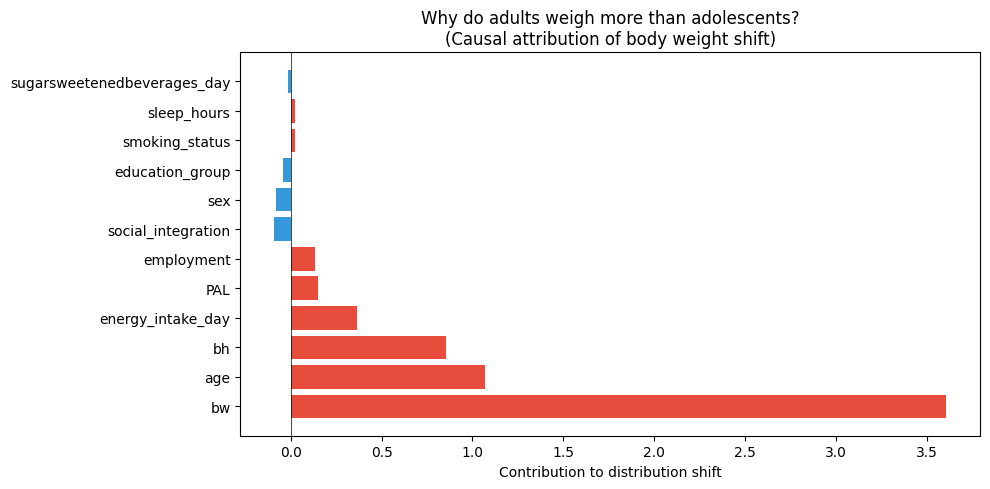

In [45]:
contribs = result.details["contributions"]
contribs_sorted = dict(sorted(contribs.items(), key=lambda x: abs(x[1]), reverse=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in contribs_sorted.values()]
ax.barh(list(contribs_sorted.keys()), list(contribs_sorted.values()), color=colors)
ax.set_xlabel("Contribution to distribution shift")
ax.set_title("Why do adults weigh more than adolescents?\n(Causal attribution of body weight shift)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 7. Causal Effect Curve

**Clinical question**: *How does body weight change as daily energy intake increases from 500 to 5000 kcal? Is the relationship linear, or is there a some other effect at high caloric intake?*


In [18]:
task = CausalEffectCurve(
    treatment="energy_intake_day",
    outcome="bw",
    n_points=15,
    num_samples=2000,
)

result = model.run(task)
result.summary()

'Causal Effect Curve\n───────────────────\n  Estimate:     treatment_value  expected_outcome        std\n0         -9.000000         76.321416  13.399575\n1        961.888571         75.316351  12.472597\n2       1932.777143         71.904479  12.526508\n3       2903.665714         77.420867  12.936008\n4       3874.554286         78.430172  13.033532\n5       4845.442857         79.465826  13.680053\n6       5816.331429         79.141222  13.178569\n7       6787.220000         78.940151  13.104310\n8       7758.108571         79.266748  12.969934\n9       8728.997143         78.444719  13.338401\n10      9699.885714         78.430945  13.239581\n11     10670.774286         79.331612  13.093135\n12     11641.662857         78.858325  12.845892\n13     12612.551429         79.417541  13.031715\n14     13583.440000         79.400966  13.007663\n  Treatment: energy_intake_day\n  Outcome: bw\n  Responses:\n    treatment_value=↓ -9.0000  |  expected_outcome=↑ 76.3214  |  std=↑ 13.3996\n    

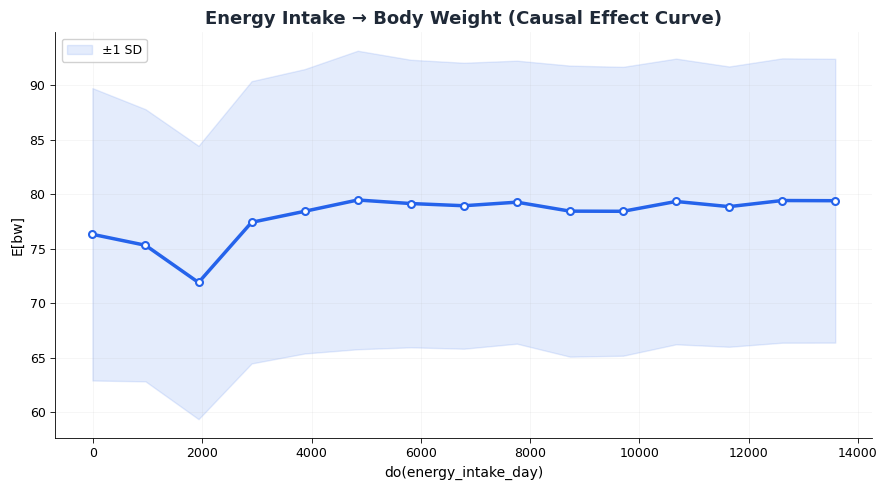

In [19]:
from causalpype.plotting import plot_causal_effect_curve
fig, ax = plot_causal_effect_curve(result,
    title="Energy Intake → Body Weight (Causal Effect Curve)")

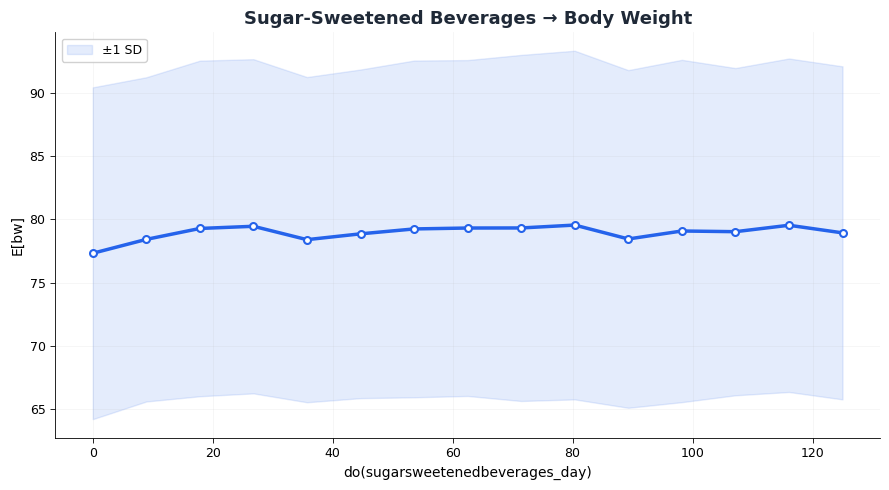

In [20]:
task_ssb = CausalEffectCurve(
    treatment="sugarsweetenedbeverages_day",
    outcome="bw",
    n_points=15,
    num_samples=2000,
)

result_ssb = model.run(task_ssb)
fig, ax = plot_causal_effect_curve(result_ssb,
    title="Sugar-Sweetened Beverages → Body Weight")

## 8. FairnessAudit

**Clinical question**: *Is body weight causally influenced by sex beyond what is explained by legitimate biological mediators like height? If we could counterfactually change every patient's sex while keeping their individual characteristics (genetics, lifestyle, diet) intact, how much would their weight change?*


In [22]:
task = FairnessAudit(
    protected_attribute="sex",
    outcome="bw",
    privileged_value=1,    # male
    unprivileged_value=2,  # female
)

result = model.run(task)
result.summary()

'Fairness Audit\n──────────────\n  Estimate: ↑ 2.6046\n  Protected Attribute: sex\n  Outcome: bw\n  Counterfactual Disparity: ↑ 2.6046\n  Observational Gap: ↑ 8.8884\n  Mean Individual Unfairness: ↑ 9.2896\n  Max Individual Unfairness: ↑ 75.2701\n  N Privileged: 6,171\n  N Unprivileged: 8,032'

In [23]:
obs_gap = result.details["observational_gap"]
cf_gap = result.details["counterfactual_disparity"]

print(f"Observational gap (male - female):    {obs_gap:+.2f} kg")
print(f"Counterfactual disparity:             {cf_gap:+.2f} kg")
print(f"Explained by mediators (e.g. height): {obs_gap - cf_gap:+.2f} kg")

Observational gap (male - female):    +8.89 kg
Counterfactual disparity:             +2.60 kg
Explained by mediators (e.g. height): +6.28 kg


In [24]:
task_edu = FairnessAudit(
    protected_attribute="education_group",
    outcome="bw",
    privileged_value=4,    # highest education
    unprivileged_value=1,  # lowest education
)

result_edu = model.run(task_edu)
result_edu.summary()

'Fairness Audit\n──────────────\n  Estimate: ↓ -0.4352\n  Protected Attribute: education_group\n  Outcome: bw\n  Counterfactual Disparity: ↓ -0.4352\n  Observational Gap: ↑ 6.7717\n  Mean Individual Unfairness: ↑ 5.1918\n  Max Individual Unfairness: ↑ 31.2620\n  N Privileged: 1,989\n  N Unprivileged: 9,383'

## 9. Intervention

**Clinical question**: *If a public health program mandated 8 hours of sleep and 2000 kcal/day energy intake for the entire population, what would the expected body weight distribution look like? How does this compare to the observed population?*


In [26]:
# Baseline: no intervention (observe natural distribution)
baseline = Intervention(
    interventions={},
    outcome="bw",
    num_samples=5000,
)

# Policy: mandate sleep + caloric intake
policy = Intervention(
    interventions={"sleep_hours": 8.0, "energy_intake_day": 2000},
    outcome="bw",
    num_samples=5000,
)

result_baseline = model.run(baseline)
result_policy = model.run(policy)

print(f"Observed mean bw:     {df['bw'].mean():.2f} kg")
print(f"Baseline (simulated): {result_baseline.estimate:.2f} kg")
print(f"Policy intervention:  {result_policy.estimate:.2f} kg")
print(f"Expected shift:       {result_policy.estimate - result_baseline.estimate:+.2f} kg")

Observed mean bw:     74.89 kg
Baseline (simulated): 76.04 kg
Policy intervention:  71.14 kg
Expected shift:       -4.90 kg


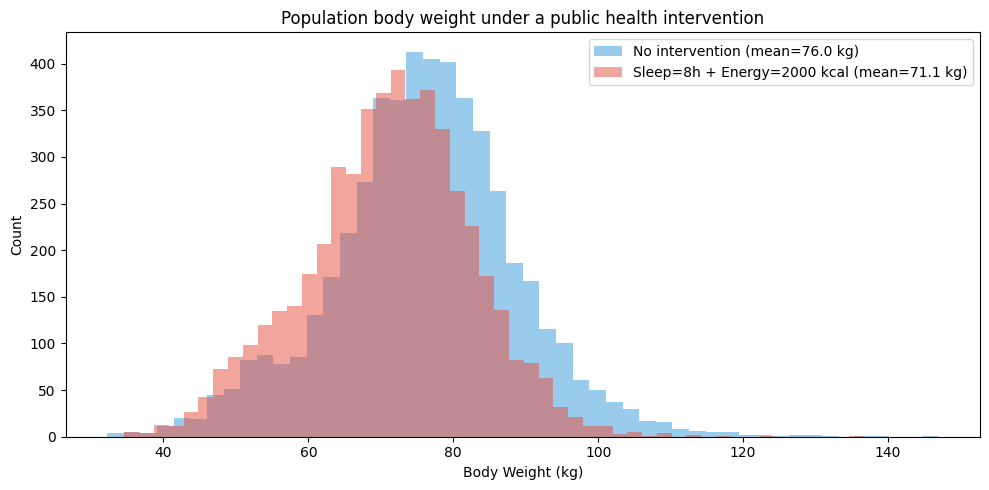

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(result_baseline.details["samples"]["bw"], bins=50, alpha=0.5,
        label=f'No intervention (mean={result_baseline.estimate:.1f} kg)', color="#3498db")
ax.hist(result_policy.details["samples"]["bw"], bins=50, alpha=0.5,
        label=f'Sleep=8h + Energy=2000 kcal (mean={result_policy.estimate:.1f} kg)', color="#e74c3c")
ax.set_xlabel("Body Weight (kg)")
ax.set_ylabel("Count")
ax.set_title("Population body weight under a public health intervention")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Intrinsic Causal Influence

**Clinical question**: *What fraction of the variance in body weight is attributable to each upstream causal factor? Is weight variation primarily driven by unexplained factors (bw's own noise), or by modifiable causes like diet, sleep, and physical activity?*


In [29]:
task = IntrinsicCausalInfluence(target="bw")
result = model.run(task)
result.summary()

Evaluating set functions...: 100%|██████████| 242/242 [00:24<00:00,  9.88it/s]


'Intrinsic Causal Influence\n──────────────────────────\n  Estimate:\n    age: ↑ 57.2986\n    education_group: ↑ 0.2002\n    energy_intake_day: ↑ 11.4909\n    sex: ↑ 10.5384\n    social_integration: ↑ 1.3060\n    sugarsweetenedbeverages_day: ↑ 2.8382\n    smoking_status: ↑ 0.0324\n    sleep_hours: ↑ 0.1035\n    employment: ↑ 1.5523\n    bh: ↑ 25.4195\n    PAL: ↑ 3.3590\n    bw: ↑ 17.5508\n  Target: bw\n  Normalized:\n    age                                 ↑ 0.4351\n    bh                                  ↑ 0.1930\n    bw                                  ↑ 0.1333\n    energy_intake_day                   ↑ 0.0873\n    sex                                 ↑ 0.0800\n    PAL                                 ↑ 0.0255\n    sugarsweetenedbeverages_day         ↑ 0.0216\n    employment                          ↑ 0.0118\n    social_integration                  ↑ 0.0099\n    education_group                     ↑ 0.0015\n    sleep_hours                         ↑ 0.0008\n    smoking_status           

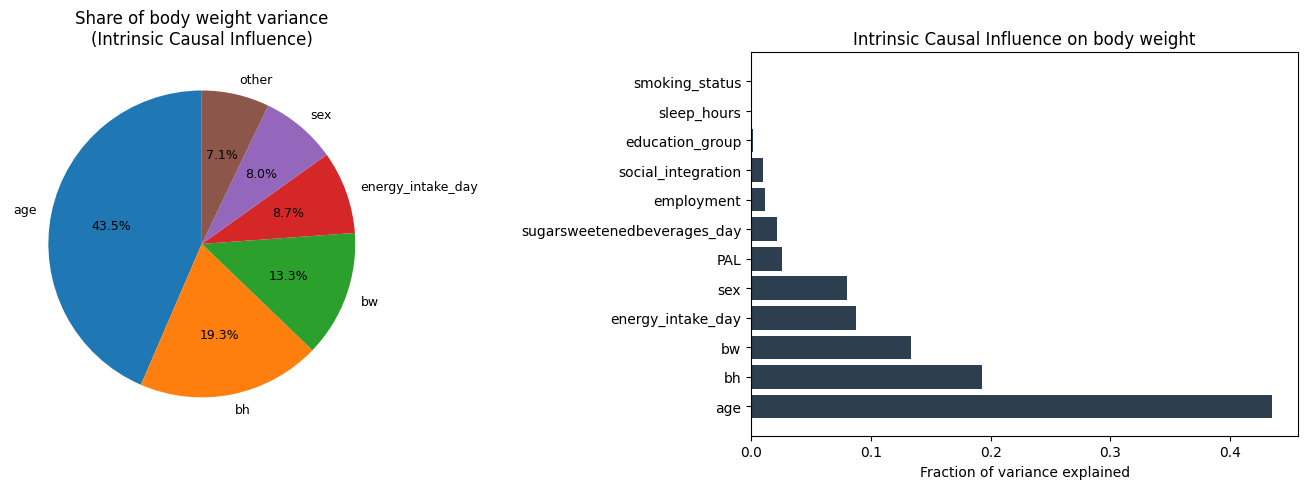

In [30]:
import matplotlib.pyplot as plt

normalized = result.details["normalized"]
norm_sorted = dict(sorted(normalized.items(), key=lambda x: x[1], reverse=True))

# Separate significant vs negligible contributors
threshold = 0.03
major = {k: v for k, v in norm_sorted.items() if v >= threshold}
minor_sum = sum(v for v in norm_sorted.values() if v < threshold)
if minor_sum > 0:
    major["other"] = minor_sum

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(major.values(), labels=major.keys(), autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 9})
axes[0].set_title("Share of body weight variance\n(Intrinsic Causal Influence)")

# Bar chart with raw values
axes[1].barh(list(norm_sorted.keys()), list(norm_sorted.values()), color="#2c3e50")
axes[1].set_xlabel("Fraction of variance explained")
axes[1].set_title("Intrinsic Causal Influence on body weight")

plt.tight_layout()
plt.show()


## 11. KNN Intervention (Matching Estimator)

**Clinical question**: *What is the causal effect of smoking on body weight, estimated by matching each smoker to their most similar non-smokers? For each individual smoker, how much heavier (or lighter) are they compared to non-smokers who are the same age, sex, height, and activity level?*


In [32]:
task = KNNIntervention(
    treatment="smoking_status",
    outcome="bw",
    k=10,
    treatment_value=1,   # smoker
    control_value=0,     # non-smoker
    match_on=["age", "sex", "bh", "energy_intake_day", "PAL", "sleep_hours"],
)

result = model.run(task)
result.summary()

'KNN Intervention\n────────────────\n  Estimate: ↓ -0.8629\n  Treatment: smoking_status\n  Outcome: bw\n  K: 10\n  Match On: age, sex, bh, energy_intake_day, PAL, sleep_hours\n  ATE: ↓ -0.8629\n  ATT: ↓ -3.7639\n  ATC: ↑ 0.0725\n  STD ITE: ↑ 15.5253\n  Match Quality Treated: ↑ 0.6589\n  Match Quality Control: ↑ 0.9466\n  N Treated: 3,463\n  N Control: 10,740'

In [33]:
print("KNN Matching vs SCM-based estimates:")
print(f"  KNN ATE:                   {result.details['ate']:+.2f} kg")
print(f"  KNN ATT (effect on treated): {result.details['att']:+.2f} kg")
print(f"  KNN ATC (effect on control): {result.details['atc']:+.2f} kg")
print(f"  Match quality (treated):   {result.details['match_quality_treated']:.3f}")
print(f"  Match quality (control):   {result.details['match_quality_control']:.3f}")


KNN Matching vs SCM-based estimates:
  KNN ATE:                   -0.86 kg
  KNN ATT (effect on treated): -3.76 kg
  KNN ATC (effect on control): +0.07 kg
  Match quality (treated):   0.659
  Match quality (control):   0.947


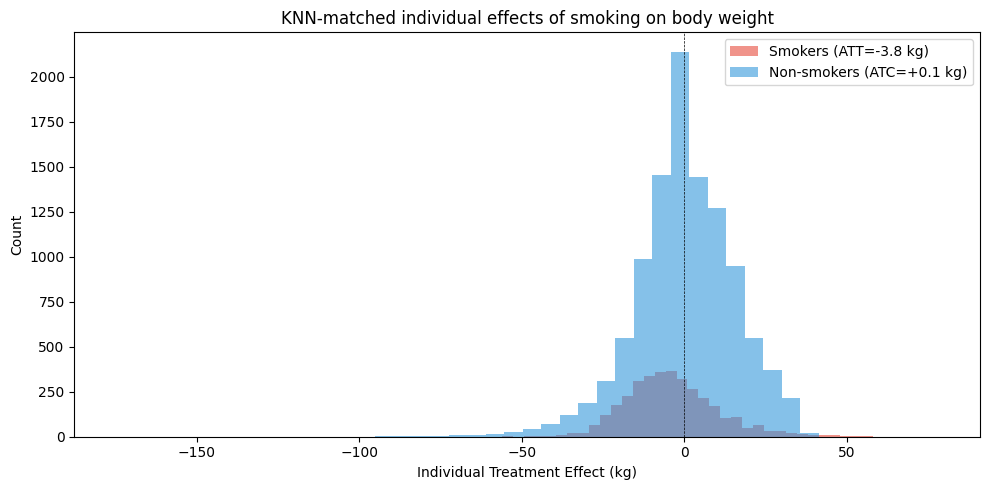

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(result.details["ite_treated"], bins=40, alpha=0.6,
        label=f"Smokers (ATT={result.details['att']:+.1f} kg)", color="#e74c3c")
ax.hist(result.details["ite_control"], bins=40, alpha=0.6,
        label=f"Non-smokers (ATC={result.details['atc']:+.1f} kg)", color="#3498db")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Individual Treatment Effect (kg)")
ax.set_ylabel("Count")
ax.set_title("KNN-matched individual effects of smoking on body weight")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Stochastic Intervention

**Clinical question**: *What if a public health campaign could reduce daily energy intake by 300 kcal across the population, not forcing everyone to a fixed value, but nudging each person's natural intake down by 300 kcal? What would be the expected impact on body weight?*


In [36]:
task = StochasticIntervention(
    treatment="energy_intake_day",
    outcome="bw",
    shift=-300,          # reduce by 300 kcal
    num_samples=5000,
)

result = model.run(task)
result.summary()

'Stochastic Intervention\n───────────────────────\n  Estimate: ↓ -1.3093\n  Treatment: energy_intake_day\n  Outcome: bw\n  Shift: -300\n  Is Binary: ✗\n  E[Y|Baseline]: ↑ 75.8748\n  E[Y|Shifted]: ↑ 74.5654\n  Effect: ↓ -1.3093'

In [37]:
shifts = [-100, -200, -300, -500, -700]
effects = []

for s in shifts:
    r = StochasticIntervention(
        treatment="energy_intake_day", outcome="bw",
        shift=s, num_samples=3000,
    )
    res = model.run(r)
    effects.append(res.estimate)
    print(f"  Shift {s:+5d} kcal → {res.estimate:+.2f} kg")


  Shift  -100 kcal → -0.50 kg
  Shift  -200 kcal → -1.56 kg
  Shift  -300 kcal → -1.64 kg
  Shift  -500 kcal → -0.99 kg
  Shift  -700 kcal → -1.06 kg


## 13. Model Validation

**Question**: *Can we trust the causal model we've built? Are the graph structure and the fitted mechanisms consistent with the observed data?*

Validation runs two complementary refutation tests:
1. **Structure validation**: tests conditional independence constraints implied by the DAG (local Markov tests + edge dependence tests). If the data violates these, the graph structure may be wrong.
2. **Model (invertibility) validation**: tests whether the fitted additive noise models are invertible, which is a core assumption of the SCM framework.


In [ ]:
task = Validate(method="all", significance_level=0.05)
result = model.run(task)
result.summary()

In [ ]:
import causalpype as cp
from causalpype import (
    Pipeline, AnomalyAttribution, ArrowStrength, ATE, CATE,
    Counterfactual, DistributionChange, CausalEffectCurve,
    FairnessAudit, Intervention, IntrinsicCausalInfluence,
    KNNIntervention, StochasticIntervention, Validate,
)

model = cp.CausalModel(G)
model.fit(df)

tasks = [
    AnomalyAttribution(target="bw", anomaly_threshold_percentile=95),
    ArrowStrength(target="bw"),
    ATE(treatment="smoking_status", outcome="bw", treatment_value=1, control_value=0, num_samples=5000),
    CATE(treatment="smoking_status", outcome="bw", effect_modifiers=["age", "sex"], method="linear_dml"),
    Counterfactual(interventions={"PAL": 1.5, "sleep_hours": 8.0}, observed_data=obese, outcome="bw"),
    DistributionChange(target="bw", old_data=young, new_data=adult, num_samples=3000),
    CausalEffectCurve(treatment="energy_intake_day", outcome="bw", n_points=15, num_samples=2000),
    FairnessAudit(protected_attribute="sex", outcome="bw", privileged_value=1, unprivileged_value=2),
    Intervention(interventions={"sleep_hours": 8.0, "energy_intake_day": 2000}, outcome="bw", num_samples=5000),
    IntrinsicCausalInfluence(target="bw"),
    KNNIntervention(treatment="smoking_status", outcome="bw", k=10, treatment_value=1, control_value=0,
                    match_on=["age", "sex", "bh", "energy_intake_day", "PAL", "sleep_hours"]),
    StochasticIntervention(treatment="energy_intake_day", outcome="bw", shift=-300, num_samples=5000),
    Validate(method="all", significance_level=0.05),
]

pipeline = Pipeline(model)
results = pipeline.run(tasks)

print(pipeline.summary())
